In [31]:
import os

os.environ['KAGGLE_USERNAME'] = 'KAGGLE_KEY'
os.environ['KAGGLE_KEY']      = 'KAGGLE_USERNAME'
!pip install kaggle -q
!kaggle datasets download -d sobhanmoosavi/us-accidents --unzip -q

print('Dataset downloaded!')
!ls -lh *.csv

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
Dataset downloaded!
-rw-r--r-- 1 root root 2.9G Jun 29 14:04 US_Accidents_March23.csv


## Step 2: Import Libraries

In [17]:
!pip install folium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries imported!')

Libraries imported!


In [18]:
df = pd.read_csv('US_Accidents_March23.csv', nrows=500000)

print(f'Dataset loaded!')
print(f'Shape: {df.shape}')
df.head(3)

Dataset loaded!
Shape: (500000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day


## Step 4: Explore Data

In [19]:
print('Basic Info')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\nNull % (top columns)')
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].head(10).round(2))

print('\nSeverity Distribution')
print(df['Severity'].value_counts().sort_index())

Basic Info
Rows: 500,000  |  Columns: 46

Null % (top columns)
End_Lng              100.00
End_Lat              100.00
Precipitation(in)     89.61
Wind_Chill(F)         87.53
Wind_Speed(mph)       17.81
Visibility(mi)         2.11
Weather_Condition      2.04
Humidity(%)            1.58
Temperature(F)         1.45
Pressure(in)           1.15
dtype: float64

Severity Distribution
Severity
1       388
2    312159
3    187173
4       280
Name: count, dtype: int64


In [20]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Hour']      = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()
df['Month']     = df['Start_Time'].dt.month_name()
df['Year']      = df['Start_Time'].dt.year

def simplify_weather(w):
    if pd.isna(w): return 'Unknown'
    w = w.lower()
    if 'clear' in w or 'fair' in w: return 'Clear'
    if 'cloud' in w or 'overcast' in w: return 'Cloudy'
    if 'rain' in w or 'drizzle' in w: return 'Rain'
    if 'snow' in w or 'sleet' in w or 'ice' in w or 'wintry' in w: return 'Snow/Ice'
    if 'fog' in w or 'mist' in w or 'haze' in w: return 'Fog/Mist'
    if 'thunder' in w or 'storm' in w: return 'Thunderstorm'
    if 'wind' in w: return 'Windy'
    return 'Other'

df['Weather_Simple'] = df['Weather_Condition'].apply(simplify_weather)
df['Severity_Label'] = df['Severity'].map({1:'Low', 2:'Moderate', 3:'High', 4:'Critical'})

print('Preprocessing done!')
df[['Hour','DayOfWeek','Month','Weather_Simple','Severity_Label']].head()

Preprocessing done!


,Hour,DayOfWeek,Month,Weather_Simple,Severity_Label
0,5,Monday,February,Rain,High
1,6,Monday,February,Rain,Moderate
2,6,Monday,February,Cloudy,Moderate
3,7,Monday,February,Cloudy,High
4,7,Monday,February,Cloudy,Moderate


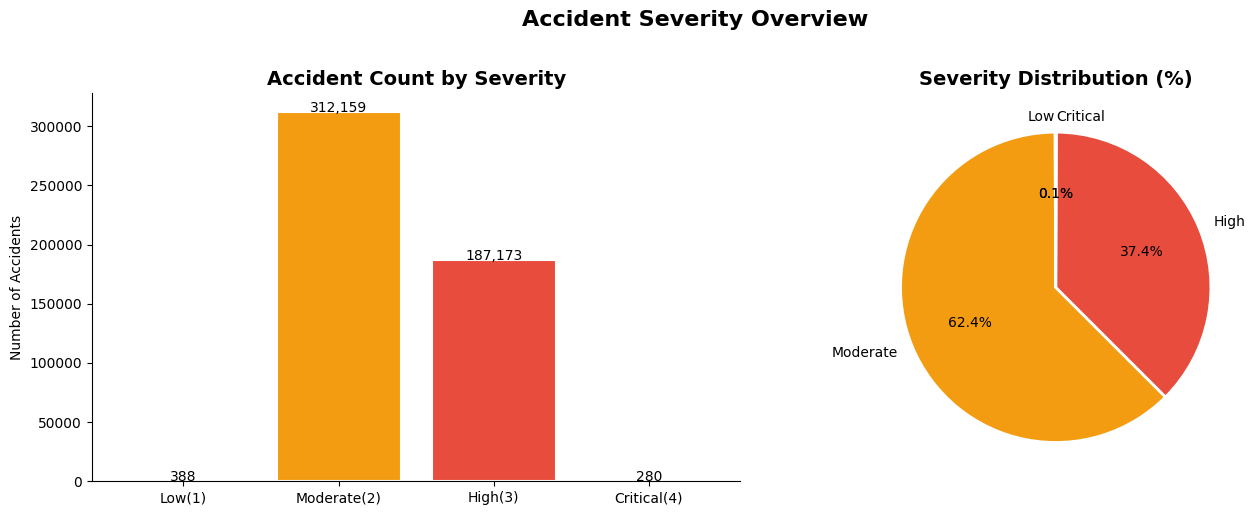

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

severity_counts = df['Severity'].value_counts().sort_index()
colors = ['#2ecc71','#f39c12','#e74c3c','#8e44ad']

bars = axes[0].bar(['Low(1)','Moderate(2)','High(3)','Critical(4)'],
                   severity_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Accident Count by Severity', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Accidents')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=10)

axes[1].pie(severity_counts.values, labels=['Low','Moderate','High','Critical'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Severity Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Accident Severity Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_severity.png', dpi=150, bbox_inches='tight')
plt.show()

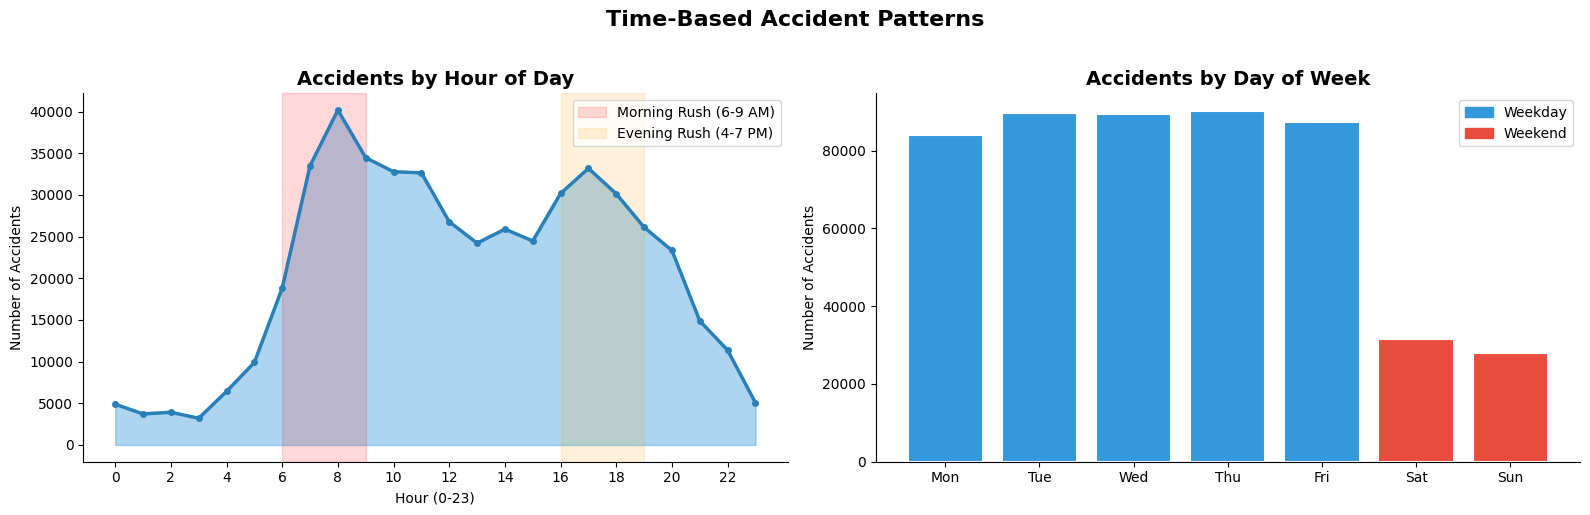

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly = df.groupby('Hour').size().reset_index(name='Count')
axes[0].fill_between(hourly['Hour'], hourly['Count'], alpha=0.4, color='#3498db')
axes[0].plot(hourly['Hour'], hourly['Count'], color='#2980b9', linewidth=2.5, marker='o', markersize=4)
axes[0].axvspan(6, 9, alpha=0.15, color='red', label='Morning Rush (6-9 AM)')
axes[0].axvspan(16, 19, alpha=0.15, color='orange', label='Evening Rush (4-7 PM)')
axes[0].set_title('Accidents by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Number of Accidents')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('DayOfWeek').size().reindex(day_order)
bar_colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in day_order]
axes[1].bar(range(7), daily.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Accidents by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Accidents')
axes[1].legend(handles=[Patch(color='#3498db', label='Weekday'), Patch(color='#e74c3c', label='Weekend')])

plt.suptitle('Time-Based Accident Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

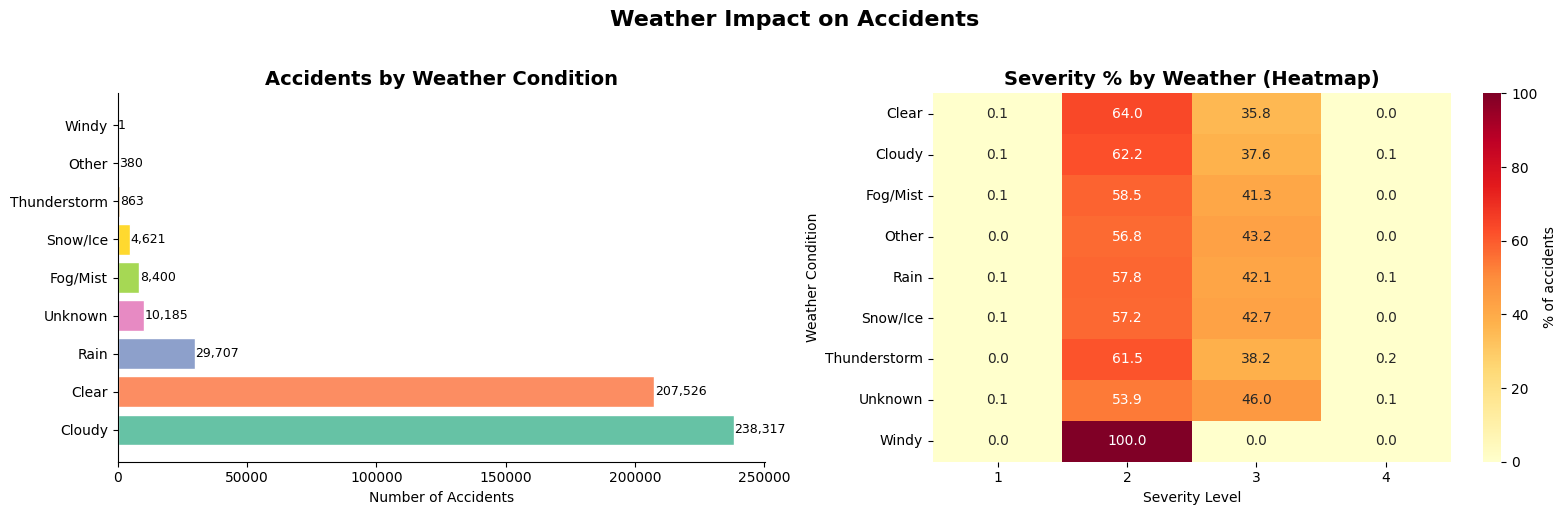

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weather_counts = df['Weather_Simple'].value_counts()
axes[0].barh(weather_counts.index, weather_counts.values,
             color=sns.color_palette('Set2', len(weather_counts)), edgecolor='white')
axes[0].set_title('Accidents by Weather Condition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
for i, v in enumerate(weather_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

weather_severity = df.groupby(['Weather_Simple','Severity']).size().unstack(fill_value=0)
weather_severity_pct = weather_severity.div(weather_severity.sum(axis=1), axis=0) * 100
sns.heatmap(weather_severity_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '% of accidents'})
axes[1].set_title('Severity % by Weather (Heatmap)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Weather Condition')

plt.suptitle('Weather Impact on Accidents', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

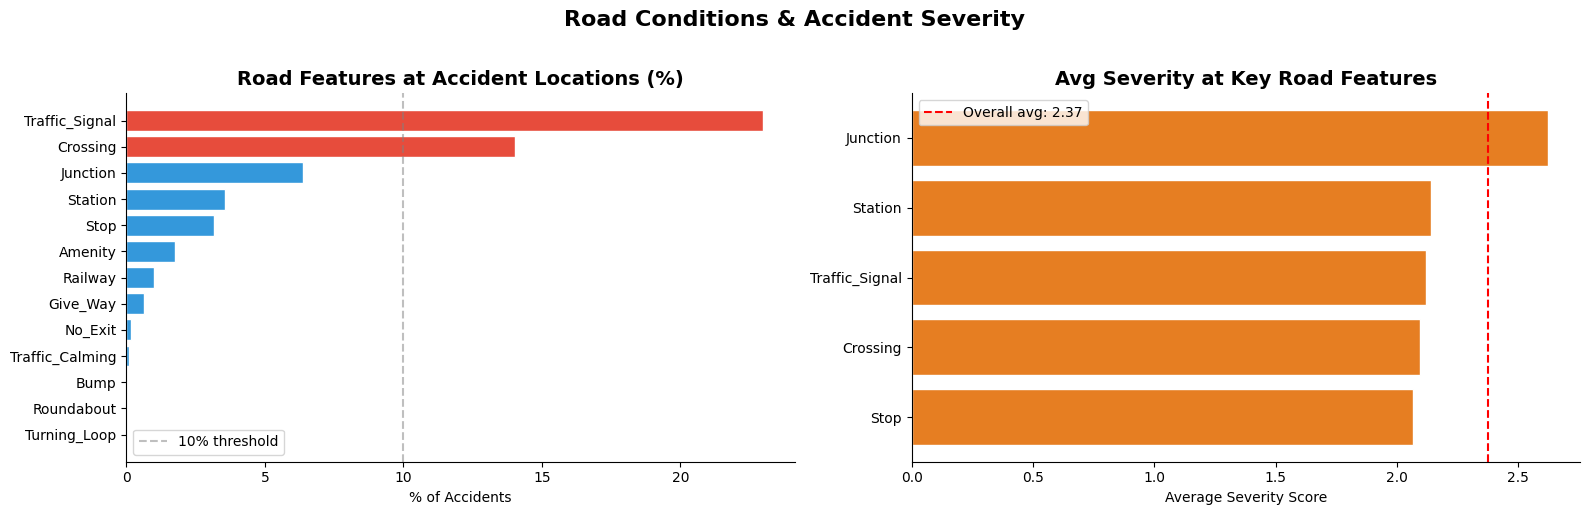

In [24]:
road_features = ['Amenity','Bump','Crossing','Give_Way','Junction','No_Exit',
                 'Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop']
road_features = [f for f in road_features if f in df.columns]

road_pct = df[road_features].mean() * 100
road_pct = road_pct.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_road = ['#e74c3c' if v > 10 else '#3498db' for v in road_pct.values]
axes[0].barh(road_pct.index, road_pct.values, color=colors_road, edgecolor='white')
axes[0].set_title('Road Features at Accident Locations (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('% of Accidents')
axes[0].axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='10% threshold')
axes[0].legend()

top_road = road_pct.tail(5).index.tolist()
severity_road = {}
for feat in top_road:
    avg_sev = df.groupby(feat)['Severity'].mean()
    severity_road[feat] = avg_sev.get(True, 0)

sr_df = pd.Series(severity_road).sort_values()
axes[1].barh(sr_df.index, sr_df.values, color='#e67e22', edgecolor='white')
axes[1].set_title('Avg Severity at Key Road Features', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Severity Score')
axes[1].axvline(x=df['Severity'].mean(), color='red', linestyle='--',
                label=f'Overall avg: {df["Severity"].mean():.2f}')
axes[1].legend()

plt.suptitle('Road Conditions & Accident Severity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_road_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
sample = df[['Start_Lat','Start_Lng','Severity']].dropna().sample(n=50000, random_state=42)

m = folium.Map(location=[37.09, -95.71], zoom_start=4, tiles='CartoDB dark_matter')

heat_data = [[row['Start_Lat'], row['Start_Lng'], row['Severity']]
             for _, row in sample.iterrows()]

HeatMap(heat_data, min_opacity=0.3, max_zoom=13, radius=8, blur=5,
        gradient={0.2:'blue', 0.4:'lime', 0.6:'orange', 1.0:'red'}).add_to(m)

title_html = '''
    <div style="position:fixed;top:10px;left:50px;z-index:9999;
         background-color:rgba(0,0,0,0.7);padding:10px 20px;
         border-radius:8px;color:white;font-size:16px;font-weight:bold;">
        🗺️ US Traffic Accident Hotspots (Weighted by Severity)
    </div>
'''
m.get_root().html.add_child(folium.Element(title_html))
m.save('05_hotspot_map.html')
print('Interactive map saved!')
m

Interactive map saved!


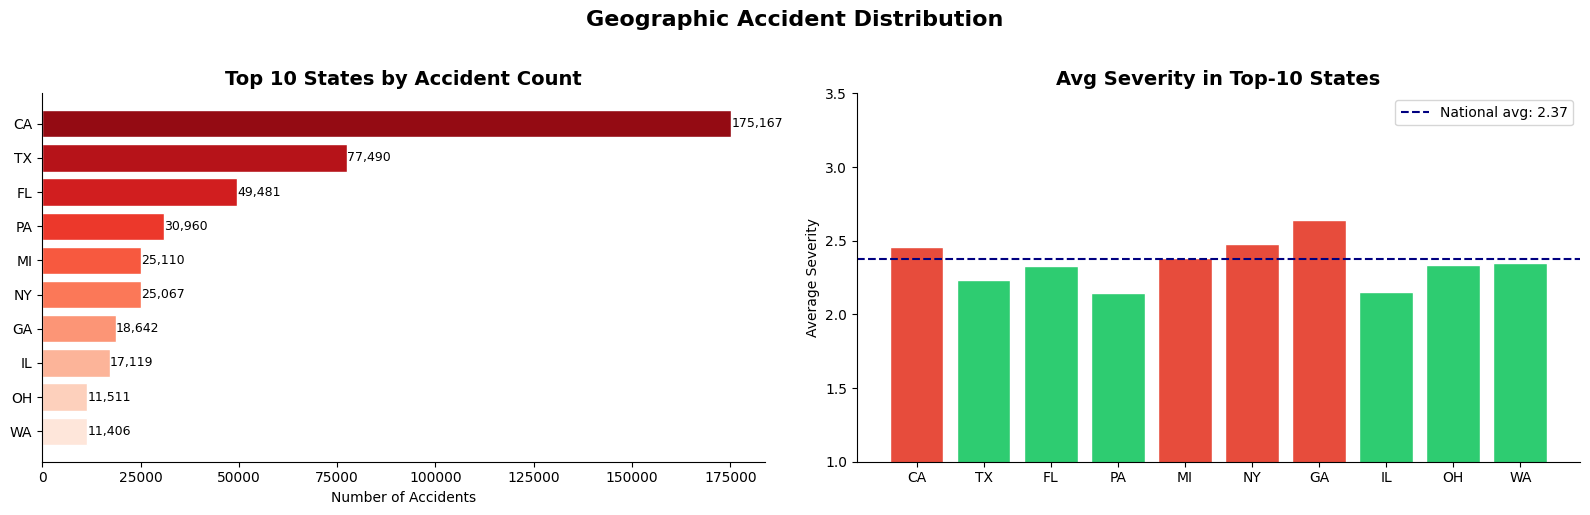

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_states = df['State'].value_counts().head(10)
colors_state = sns.color_palette('Reds_r', 10)
axes[0].barh(top_states.index[::-1], top_states.values[::-1], color=colors_state[::-1], edgecolor='white')
axes[0].set_title('Top 10 States by Accident Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
for i, v in enumerate(top_states.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

state_severity = df[df['State'].isin(top_states.index)].groupby('State')['Severity'].mean().reindex(top_states.index)
bar_colors2 = ['#e74c3c' if s > df['Severity'].mean() else '#2ecc71' for s in state_severity.values]
axes[1].bar(state_severity.index, state_severity.values, color=bar_colors2, edgecolor='white')
axes[1].axhline(y=df['Severity'].mean(), color='navy', linestyle='--',
                label=f'National avg: {df["Severity"].mean():.2f}')
axes[1].set_title('Avg Severity in Top-10 States', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Severity')
axes[1].set_ylim(1, 3.5)
axes[1].legend()

plt.suptitle('Geographic Accident Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

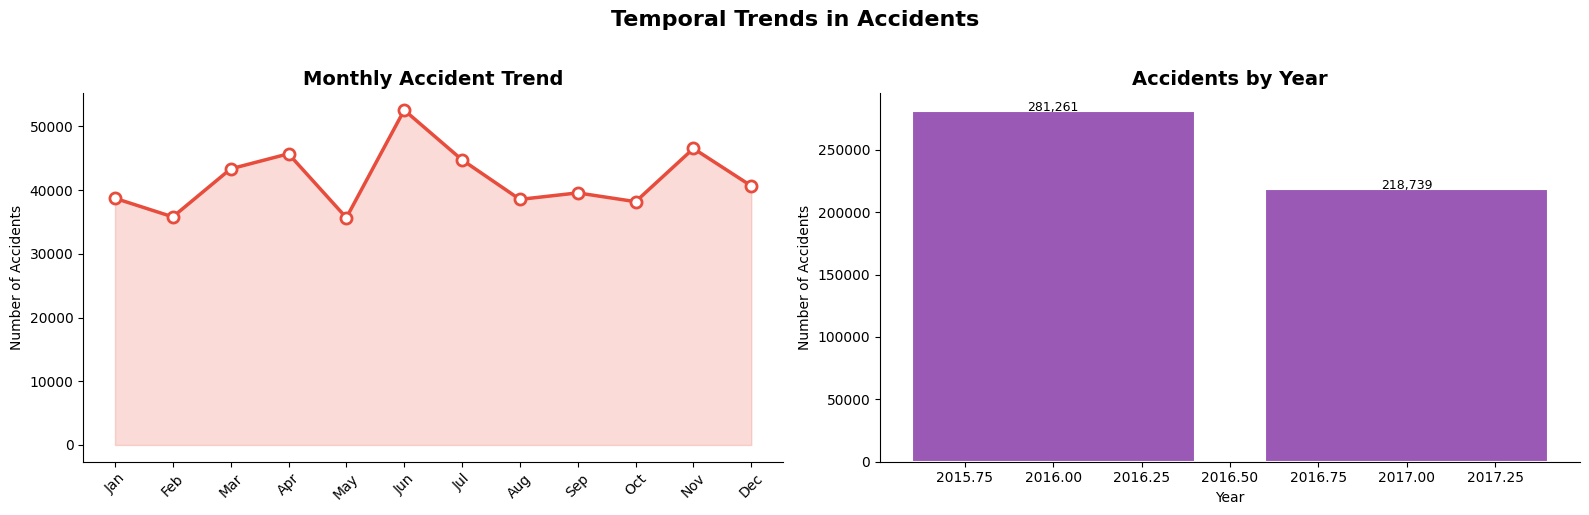

In [27]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly = df.groupby('Month').size().reindex(month_order)
axes[0].plot(range(12), monthly.values, marker='o', linewidth=2.5,
             color='#e74c3c', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(range(12), monthly.values, alpha=0.2, color='#e74c3c')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0].set_title('Monthly Accident Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Accidents')

yearly = df.groupby('Year').size()
axes[1].bar(yearly.index, yearly.values, color='#9b59b6', edgecolor='white', linewidth=1.5)
axes[1].set_title('Accidents by Year', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Accidents')
axes[1].set_xlabel('Year')
for yr, cnt in yearly.items():
    axes[1].text(yr, cnt + 200, f'{cnt:,}', ha='center', fontsize=9)

plt.suptitle('Temporal Trends in Accidents', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

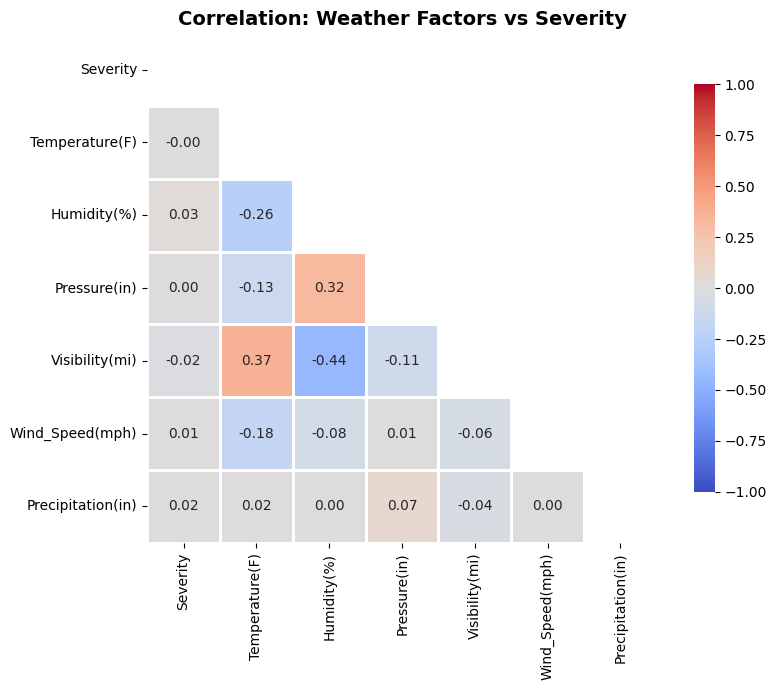

In [28]:
num_cols = ['Severity','Temperature(F)','Humidity(%)','Pressure(in)',
            'Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
num_cols = [c for c in num_cols if c in df.columns]

corr_df = df[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=1, cbar_kws={'shrink':0.8}, vmin=-1, vmax=1, center=0)
ax.set_title('Correlation: Weather Factors vs Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print('KEY INSIGHTS — US Traffic Accident Analysis')

print(f'\nTotal Records Analyzed : {len(df):,}')
print(f' Date Range : {df["Start_Time"].min().date()} to {df["Start_Time"].max().date()}')

print('\nTIME PATTERNS:')
peak_hour = df['Hour'].value_counts().idxmax()
print(f' Peak accident hour : {peak_hour}:00 ({"AM" if peak_hour < 12 else "PM"})')
print(f' Most accidents on  : {df["DayOfWeek"].value_counts().idxmax()}')
print(f' Peak month         : {df["Month"].value_counts().idxmax()}')

print('\n WEATHER:')
print(f'  Most accidents in  : {df["Weather_Simple"].value_counts().idxmax()} conditions')
worst_weather = df.groupby('Weather_Simple')['Severity'].mean().idxmax()
print(f'  Highest severity   : {worst_weather}')

print('\n SEVERITY:')
print(f' Average severity   : {df["Severity"].mean():.2f} / 4.0')
print(f' Critical (Level 4) : {(df["Severity"]==4).sum():,} ({(df["Severity"]==4).mean()*100:.1f}%)')

print('\n LOCATION:')
print(f' Most accidents     : {df["State"].value_counts().index[0]}')
print(f' Highest severity   : {df.groupby("State")["Severity"].mean().idxmax()}')


print('Analysis Complete!')
print('Pragya Priya Sahoo | Prodigy Infotech — Task 05')


KEY INSIGHTS — US Traffic Accident Analysis

Total Records Analyzed : 500,000
 Date Range : 2016-02-08 to 2017-07-30

TIME PATTERNS:
 Peak accident hour : 8:00 (AM)
 Most accidents on  : Thursday
 Peak month         : June

 WEATHER:
  Most accidents in  : Cloudy conditions
  Highest severity   : Unknown

 SEVERITY:
 Average severity   : 2.37 / 4.0
 Critical (Level 4) : 280 (0.1%)

 LOCATION:
 Most accidents     : CA
 Highest severity   : MO
Analysis Complete!
   Pragya Priya Sahoo | Prodigy Infotech — Task 05
